<a href="https://colab.research.google.com/github/Kirthiga19/Kirthiga19/blob/main/SITS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

from google.colab import files

In [2]:
print("Please upload your dataset (CSV file)...")
uploaded = files.upload()

Please upload your dataset (CSV file)...


Saving weapons-sales dataset (1).csv to weapons-sales dataset (1).csv


In [3]:
for fn in uploaded.keys():
    filename = fn

In [4]:
df = pd.read_csv(filename)
print("Dataset Preview:")
print(df.head())

Dataset Preview:
  Rank (2021)  Rank (2020)            Company (c)  Notes (2021)  \
0            1           1   Lockheed Martin Corp.          NaN   
1            2           2   Raytheon Technologies          NaN   
2            3           3                  Boeing          NaN   
3            4           4  Northrop Grumman Corp.          NaN   
4            5           5  General Dynamics Corp.          NaN   

     Country (d)  Arms Sales (2021)  Arms sales (2020) Total Sales (2021)  \
0  United States            60340.0            58210.0              67044   
1  United States            41850.0            36780.0              64388   
2  United States            33420.0            32740.0              62286   
3  United States            29880.0            30420.0              35667   
4  United States            26390.0            25840.0              38469   

  Arms sales as a % of total sales (2021)  \
0                                      90   
1                          

In [6]:
X = df.drop("Arms Sales (2021)", axis=1)
y = df["Arms Sales (2021)"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Convert 'Rank (2020)' to numeric, coercing errors to NaN
X_train['Rank (2020)'] = pd.to_numeric(X_train['Rank (2020)'], errors='coerce')
X_test['Rank (2020)'] = pd.to_numeric(X_test['Rank (2020)'], errors='coerce')

# Identify all remaining non-numeric columns (object type)
object_cols = X_train.select_dtypes(include='object').columns.tolist()

# Drop these object columns
X_train_numeric = X_train.drop(columns=object_cols)
X_test_numeric = X_test.drop(columns=object_cols)

# Drop rows with NaN values from both features and target variable to ensure alignment
train_data = pd.concat([X_train_numeric, y_train], axis=1).dropna()
X_train_final = train_data.drop(columns=['Arms Sales (2021)'])
y_train_final = train_data['Arms Sales (2021)']

test_data = pd.concat([X_test_numeric, y_test], axis=1).dropna()
X_test_final = test_data.drop(columns=['Arms Sales (2021)'])
y_test_final = test_data['Arms Sales (2021)']

lin_model = LinearRegression()
lin_model.fit(X_train_final, y_train_final)
lin_pred = lin_model.predict(X_test_final)

print("\n--- Linear Regression ---")
print("R²:", r2_score(y_test_final, lin_pred))
print("MSE:", mean_squared_error(y_test_final, lin_pred))


--- Linear Regression ---
R²: 0.9953291357031543
MSE: 857110.0022261305


In [12]:
y_binary = (y > y.median()).astype(int)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Convert 'Rank (2020)' to numeric, coercing errors to NaN
X_train_bin['Rank (2020)'] = pd.to_numeric(X_train_bin['Rank (2020)'], errors='coerce')
X_test_bin['Rank (2020)'] = pd.to_numeric(X_test_bin['Rank (2020)'], errors='coerce')

# Identify all remaining non-numeric columns (object type)
object_cols_bin = X_train_bin.select_dtypes(include='object').columns.tolist()

# Drop these object columns
X_train_bin_numeric = X_train_bin.drop(columns=object_cols_bin)
X_test_bin_numeric = X_test_bin.drop(columns=object_cols_bin)

# Drop rows with NaN values from both features and target variable to ensure alignment
train_data_bin = pd.concat([X_train_bin_numeric, y_train_bin], axis=1).dropna()
X_train_bin_final = train_data_bin.drop(columns=['Arms Sales (2021)']) # Assuming 'Arms Sales (2021)' was the original name of y_binary's source
y_train_bin_final = train_data_bin['Arms Sales (2021)']

test_data_bin = pd.concat([X_test_bin_numeric, y_test_bin], axis=1).dropna()
X_test_bin_final = test_data_bin.drop(columns=['Arms Sales (2021)'])
y_test_bin_final = test_data_bin['Arms Sales (2021)']

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_bin_final, y_train_bin_final)
log_pred = log_model.predict(X_test_bin_final)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test_bin_final, log_pred))
print("\nClassification Report:\n", classification_report(y_test_bin_final, log_pred))


--- Logistic Regression ---
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



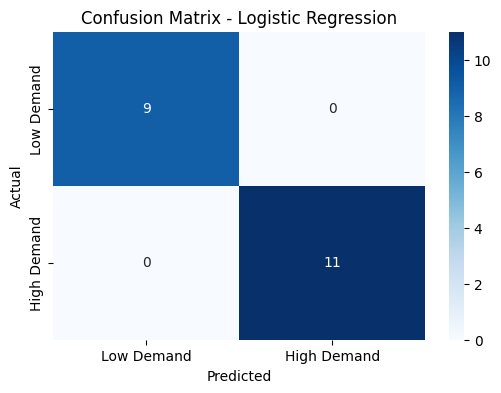

In [14]:
cm = confusion_matrix(y_test_bin_final, log_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low Demand","High Demand"], yticklabels=["Low Demand","High Demand"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [16]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_final, y_train_final)
tree_pred = tree_model.predict(X_test_final)

print("\n--- Decision Tree ---")
print("R²:", r2_score(y_test_final, tree_pred))
print("MSE:", mean_squared_error(y_test_final, tree_pred))


--- Decision Tree ---
R²: 0.8993461198717693
MSE: 18470125.0


In [18]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_final, y_train_final)
rf_pred = rf_model.predict(X_test_final)

print("\n--- Random Forest ---")
print("R²:", r2_score(y_test_final, rf_pred))
print("MSE:", mean_squared_error(y_test_final, rf_pred))


--- Random Forest ---
R²: 0.8700256656638277
MSE: 23850468.545500007


In [21]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy/Score": [
        r2_score(y_test_final, lin_pred),              # R² for regression
        accuracy_score(y_test_bin_final, log_pred),    # Accuracy for classification
        r2_score(y_test_final, tree_pred),             # R² for regression
        r2_score(y_test_final, rf_pred)                # R² for regression
    ]
})

print("\n=== Final Model Accuracy/Performance Summary ===")
print(results)


=== Final Model Accuracy/Performance Summary ===
                 Model  Accuracy/Score
0    Linear Regression        0.995329
1  Logistic Regression        1.000000
2        Decision Tree        0.899346
3        Random Forest        0.870026


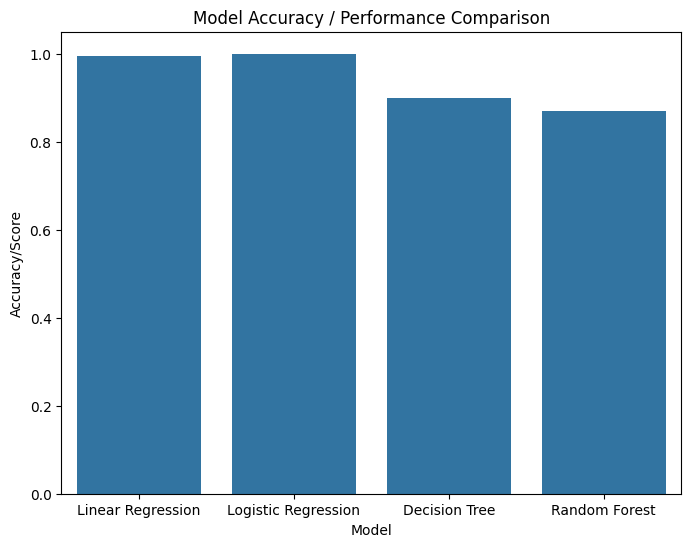

In [22]:
plt.figure(figsize=(8,6))
sns.barplot(x="Model", y="Accuracy/Score", data=results)
plt.title("Model Accuracy / Performance Comparison")
plt.show()